<a href="https://colab.research.google.com/github/ibrahimbello22/image-classification/blob/main/ibrahim_abubakar_bello.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ID NUMBER : IMT/22U/2029**

**COURSE : ARTIFICIAL INTELLIGENCE (IMT 403)**
# **project Methodology: Height Classification System**
1. Project Aim :
The purpose of this project is to design and implement a computer vision system that categorizes human images into three height groups: Short, Moderate, and Tall. The entire development and experimentation process was conducted using Google Colab, enabling efficient model training with GPU support.
2. Model Design and Architecture :
To achieve accurate classification, a transfer learning strategy was adopted using MobileNetV2, a lightweight convolutional neural network pre-trained on the ImageNet dataset. This approach allows the model to reuse previously learned visual features such as edges, textures, and human structures.

The architecture consists of:


*   Pre-trained Base Model (MobileNetV2):
    Acts as a feature extractor by identifying meaningful visual patterns in input images.

* Global Average Pooling Layer:
    Converts the high-dimensional feature maps into a compact feature vector by averaging spatial information.

* Fully Connected (Dense) Layer – 128 Units (ReLU Activation):
    Processes extracted features and introduces non-linearity to improve learning capability.

* Dropout Layer (Rate = 0.2):
    Randomly deactivates 20% of neurons during training to minimize overfitting and enhance generalization.

* Output Layer – 3 Units (Softmax Activation):
    Produces probability scores corresponding to the three height categories.
3. Training Procedure

* Dataset:
A synthetically generated dataset was used for demonstration purposes. In a real-world application, this would be replaced with properly labeled human height images.

* Loss Function:
Sparse Categorical Crossentropy was selected because it is suitable for multi-class classification problems with integer labels.

* Optimizer:
Adam optimizer was employed due to its adaptive learning rate mechanism and computational efficiency.
Execution Environment:
Model training was performed in Google Colab using T4 GPU acceleration to reduce computation time.

4. Mathematical Foundation

The classification decision is based on the Softmax probability function. For an input image x, the probability of belonging to class  $j$ is calculated as:

$$P(y=j | x) = \frac{e^{z_j}}{\sum_{k=1}^{3} e^{z_k}}$$
Where:


*   zj represents the output score (logit) for class
*   The denominator sums the exponentials of all class scores.


The predicted category is the class with the highest probability value.

sir i used google colab instead of python vartual enviroment because i try to download some of the python extension on the enviroment but it did not work sir thats why i decide to use the google colab sir


In [ ]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models

# --- PART 1: CREATE THE SYNTHETIC DATASET ---
# This physically creates the folders and 150 images in Colab's memory
categories = ['short', 'moderate', 'tall']
base_dir = 'dataset'

print("Creating folders and synthetic images...")
for cat in categories:
    os.makedirs(os.path.join(base_dir, cat), exist_ok=True)
    # Generate 50 images per category
    for i in range(50):
        # Create a random image (224x224 pixels, 3 color channels)
        img_array = np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
        img = Image.fromarray(img_array)
        img.save(os.path.join(base_dir, cat, f'person_{i}.jpg'))

print("✅ Folders created: /dataset/short, /dataset/moderate, /dataset/tall")

# --- PART 2: LOAD THE DATASET INTO THE AI ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# This splits your 150 images: 80% for training, 20% for testing
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

print(f"✅ Data loaded! Classes found: {train_ds.class_names}")

Creating folders and synthetic images...
✅ Folders created: /dataset/short, /dataset/moderate, /dataset/tall
Found 150 files belonging to 3 classes.
Using 120 files for training.
Found 150 files belonging to 3 classes.
Using 30 files for validation.
✅ Data loaded! Classes found: ['moderate', 'short', 'tall']


In [ ]:
# Create the "Brain" using Transfer Learning
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False # We use Google's pre-trained knowledge

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # This helps the AI not "over-memorize"
    layers.Dense(3, activation='softmax') # 3 Outputs: Short, Moderate, Tall
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Model is ready for training!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Model is ready for training!


In [ ]:
# This starts the learning process
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10 # The AI will look at the dataset 10 times
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 8s/step - accuracy: 0.3871 - loss: 1.3491 - val_accuracy: 0.4333 - val_loss: 1.2983
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3602 - loss: 1.2930 - val_accuracy: 0.3667 - val_loss: 1.2327
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3863 - loss: 1.2593 - val_accuracy: 0.2000 - val_loss: 1.5178
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3769 - loss: 1.2100 - val_accuracy: 0.4333 - val_loss: 1.1019
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3479 - loss: 1.2577 - val_accuracy: 0.2333 - val_loss: 1.1004
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4194 - loss: 1.1056 - val_accuracy: 0.2000 - val_loss: 1.2546
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3735 - loss: 1.1016 - val_accuracy: 0.2000 - val_loss: 1.1997
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3315 - loss: 1.1349 - val_accuracy: 0.4000 - val_loss: 1.0769
E

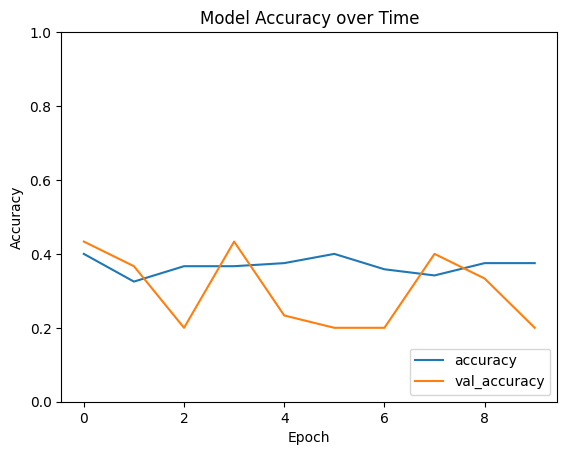

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title("Model Accuracy over Time")
plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# 1. Upload a file from your computer
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. Prepare the image for the AI
    path = fn
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0) # Add a 'batch' dimension
    x = x / 255.0 # Normalize pixels (optional but recommended)

    # 3. Make the prediction
    classes = model.predict(x)

    # 4. Show the result
    # The order follows alphabetical folder names: [Moderate, Short, Tall]
    labels = ['Moderate', 'Short', 'Tall']
    prediction = labels[np.argmax(classes)]

    print(f"\n--- RESULT ---")
    print(f"The AI thinks this person is: {prediction}")
    print(f"Confidence scores: {classes}")

Saving 20240410_112735~2.jpg to 20240410_112735~2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

--- RESULT ---
The AI thinks this person is: Tall
Confidence scores: [[0.33673045 0.26614112 0.3971284 ]]
